In [167]:
import numpy as np
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt

In [168]:
adata = sc.read_h5ad("../../../project_folder/output/loops/data/loop2p5/replicate/adata_500k.h5ad")

In [169]:
experiments_loop_2 = ["239", 
                      "240",
                      "248",
                      "241",
                      "242",
                      "249"]

leaveout = ["243",
            "244",
            "250",
            "245",
            "246",
            "251"]

uncertainty_assignment = ["low", "high", "high", "low", "high", "high"]

In [170]:
loop_assignment = np.array(["Loop1" for _ in range(len(adata))])
loop_assignment[adata.obs["experiment_number"].isin(experiments_loop_2)] = "Loop2"

In [171]:
adata.obs["Loops"] = loop_assignment

In [172]:
uncertainty_assigment = np.array(["None" for _ in range(len(adata))])
uncertainty_assigment[adata.obs["experiment_number"].isin(["244", "250", "246", "251"])] = "high_uncertainty"
uncertainty_assigment[adata.obs["experiment_number"].isin(["243", "245"])] = "low_uncertainty"

In [173]:
# adata = adata[~adata.obs.experiment_number.isin(leaveout)]

In [174]:
cols = ['gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]',
       'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]',
       'il3_[ng_ml]', 'o2_[%]', 'days_of_culture']

In [175]:
# adata.obs = adata.obs.loc[:, cols]
adata.obs.loc[:, cols] = adata.obs.loc[:, cols].astype(float)

adata.obs = adata.obs.loc[:, cols + ["Loops"]]

/tmp/ipykernel_3414610/152872291.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[10.   10.   10.   ...  6.83  6.83  6.83]' has dtype incompatible with category, please explicitly cast to a compatible dtype first.
  adata.obs.loc[:, cols] = adata.obs.loc[:, cols].astype(float)


In [176]:
adata_unique = adata.obs.drop_duplicates()

In [177]:
adata_unique.loc[:, cols] = np.log1p(adata_unique.loc[:, cols])

/tmp/ipykernel_3414610/2278739586.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[3.09104245 3.09104245 3.09104245 3.09104245 2.63905733 2.63905733
 3.09104245 3.09104245 3.09104245 3.09104245 2.7080502  3.09104245
 2.7080502  2.7080502  2.7080502  2.7080502  2.63905733 2.63905733
 3.33220451 2.7080502  2.7080502  2.7080502  2.7080502  3.09104245
 2.7080502  2.63905733 3.36729583 2.7080502  3.61091791 3.36729583
 2.7080502  2.63905733 3.33220451 3.33220451 3.09104245 3.09104245
 3.09104245 3.09104245 2.63905733 2.7080502  3.09104245 3.09104245
 2.63905733 2.63905733 2.7080502  3.09104245 3.09104245 3.09104245
 3.09104245 3.09104245 3.33220451 2.63905733 2.63905733 2.63905733
 3.09104245 3.09104245 3.09104245 3.09104245 3.09104245 3.09104245
 2.63905733 3.09104245 2.63905733 2.63905733 2.63905733 3.09104245
 3.61091791 3.09104245 2.7080502  2.77258872 3.09104245 3.33220451
 2.77258872 2.77258872 2.63905733 3.33

In [178]:
adata_unique

,gm-csf_[ng_ml],tpo_[ng_ml],sr1_[nm],um171_[nm],um729_[µm],scf_[ng_ml],butyzamide_[nm],retinoic_acid_[µm],ldl_[ng_ml],il3_[ng_ml],o2_[%],days_of_culture,Loops
223430-121,2.397895,1.252763,5.929589,7.021976,0.000000,3.931826,0.000000,0.000000,0.00000,0.00000,3.044522,3.091042,Loop1
120579-175,2.397895,0.000000,5.929589,0.000000,0.916291,0.000000,4.615121,0.000000,0.00000,0.00000,3.044522,3.091042,Loop1
34864-165,2.397895,0.000000,5.929589,7.021976,0.000000,0.000000,4.615121,0.000000,0.00000,0.00000,3.044522,3.091042,Loop1
215693-108,2.397895,1.252763,6.621406,7.021976,0.000000,3.931826,0.000000,0.000000,0.00000,0.00000,3.044522,3.091042,Loop1
113289-72,2.397895,0.000000,5.929589,7.021976,0.000000,3.931826,4.615121,0.000000,0.00000,0.00000,3.044522,2.639057,Loop1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
30110-4,0.000000,0.000000,0.000000,4.212720,0.000000,0.000000,4.714114,0.000000,0.00000,0.00000,3.044522,2.708050,Loop2
122608-14,2.272126,1.252763,6.627115,6.986197,0.000000,3.947390,0.000000,0.182322,0.00000,2.76001,2.674149,2.708050,Loop1
58265-8,2.415914,1.223775,3.916015,0.000000,0.000000,3.703768,0.000000,0.405465,0.00000,0.00000,2.674149,2.708050,Loop2
7185-18,2.406945,0.095310,6.415424,0.000000,0.955511,3.737670,4.577799,0.000000,0.09531,0.00000,3.044522,2.708050,Loop1


## Separate again loops and protocols 

In [179]:
loops = np.array(adata_unique.loc[:, "Loops"])
protocols = adata_unique.loc[:, cols]

In [187]:
dist_mat = np.mean((protocols.values[None, :] - protocols.values[:, None])**2, axis=-1)

# np.fill_diagonal(dist_mat, np.inf)
dist_mat_pooled = dist_mat.mean(1)

dists_loop2 = dist_mat_pooled[loops=="Loop2"]

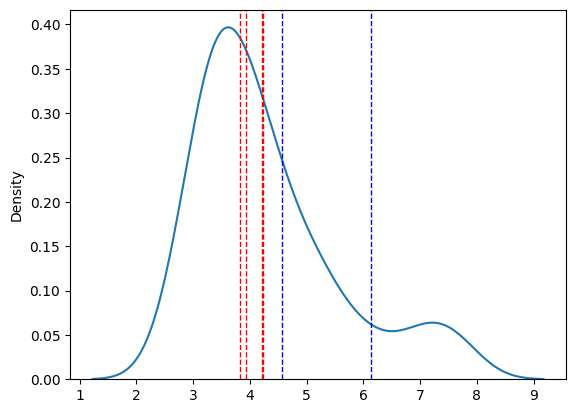

In [188]:
sns.kdeplot(dist_mat_pooled)

unc_cols = {"high": "red", 
           "low": "blue"}

for i, d in enumerate(dists_loop2):
    plt.axvline(x=d, color=unc_cols[uncertainty_assignment[i]], linestyle='--', linewidth=1)